In [2]:
import uproot

filename = "/data/elena/data/WCTE_offline_R1848S0_VME_matched.root"
tree = uproot.open(filename)["WCTEReadoutWindows"]
n_windows = tree.num_entries
print("Total readout windows:", n_windows)

Total readout windows: 1194724


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import sys
import re
import os
import glob
from matplotlib import rcParams
import random

%matplotlib inline


rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

In [4]:
path = "/data/elena/data"
filename = os.path.join(path, "WCTE_offline_R1848S0_VME_matched.root")   #already processed file for tun1848

print("Opening file:")
print(filename)

file = uproot.open(filename)

print("File contents:")
file.keys()

tree = file["WCTEReadoutWindows"]

print(tree)
tree.show()

branches = tree.keys()

print("Number of branches:", len(branches))

for name in branches:
    print(name)

Opening file:
/data/elena/data/WCTE_offline_R1848S0_VME_matched.root
File contents:
<TTree 'WCTEReadoutWindows' (37 branches) at 0x7f33e4119cf0>
name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
window_time          | double                   | AsDtype('>f8')
start_counter        | int64_t                  | AsDtype('>i8')
run_id               | int32_t                  | AsDtype('>i4')
sub_run_id           | int32_t                  | AsDtype('>i4')
spill_counter        | int32_t                  | AsDtype('>i4')
event_number         | int32_t                  | AsDtype('>i4')
readout_number       | int32_t                  | AsDtype('>i4')
trigger_types        | std::vector<int32_t>     | AsJagged(AsDtype('>i4'), he...
trigger_times        | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
led_gains            | std::vector<float>       | AsJagged(AsDtype('>f4'), h

In [8]:
import os
import sys

# 1. Definir rutas de entorno
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"  # <--- ESTA ES LA QUE FALTABA

# 2. Configurar variables de sistema
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
os.environ["PATH"] = f"{root_path}/bin:{os.environ.get('PATH', '')}"

if f"{root_path}/lib" not in sys.path:
    sys.path.append(f"{root_path}/lib")

# 3. Intentar cargar la geometría
try:
    sys.path.append("/scratch/elena/9Li/scripts")
    import functions_bonsai
    import ROOT
    
    geo_data = functions_bonsai.get_geo_mapping()
    lookup = functions_bonsai.build_lookup_table(geo_data)
    print(f"✅ ROOT y BONSAI configurados.")
    print(f"✅ Lookup generado con {len(lookup)} mPMTs.")
    
except KeyError as e:
    print(f"❌ Error: Falta la variable de entorno {e}")
except Exception as e:
    print(f"❌ Error inesperado: {e}")

✅ ROOT y BONSAI configurados.
✅ Lookup generado con 1843 mPMTs.


Lookup generado con 1843 entradas de PMTs.


/scratch/elena/conda-env/wcsim-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


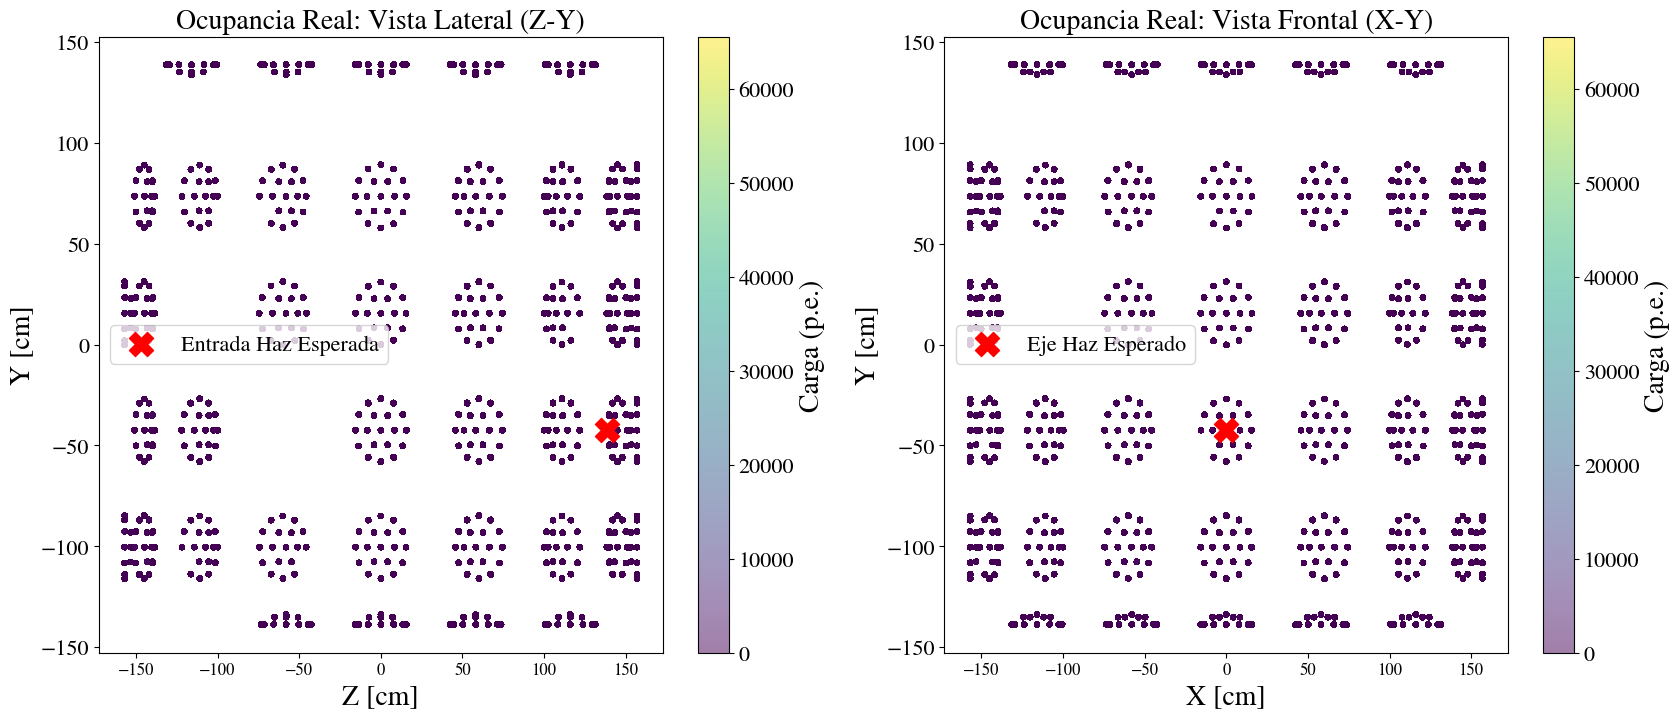

Centro de masas de la luz detectada:
X: 2.50 cm
Y: -20.83 cm
Z: 44.50 cm


In [9]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak

# 1. Cargar datos del ROOT original
filename = "/data/elena/data/WCTE_offline_R1848S0_VME_matched.root"
tree = uproot.open(filename)["WCTEReadoutWindows"]

# Leemos una cantidad manejable de eventos para el test (ej. 2000 eventos)
data = tree.arrays([
    "hit_mpmt_slot_ids", 
    "hit_pmt_position_ids", 
    "hit_pmt_charges"
], entry_stop=2000)

# --- REGENERAR EL LOOKUP TABLE ---
# Asegúrate de que las rutas a los scripts de Elena sean correctas
sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai

# Cargar la geometría oficial del detector
geo_data = functions_bonsai.get_geo_mapping()
lookup = functions_bonsai.build_lookup_table(geo_data)

print(f"Lookup generado con {len(lookup)} entradas de PMTs.")


# 2. Mapear IDs a Coordenadas usando tu 'lookup'
all_x, all_y, all_z, all_q = [], [], [], []

for slots, positions, charges in zip(data["hit_mpmt_slot_ids"], 
                                     data["hit_pmt_position_ids"], 
                                     data["hit_pmt_charges"]):
    for s, p, q in zip(slots, positions, charges):
        # Ajuste de ID si es necesario (el +1 que vimos antes)
        key = (int(s), int(p))
        if key not in lookup:
            key = (int(s), int(p) + 1)
        
        if key in lookup:
            pos = lookup[key]
            all_x.append(pos[0])
            all_y.append(pos[1])
            all_z.append(pos[2])
            all_q.append(q)

# Convertir a arrays de numpy para graficar
all_x = np.array(all_x)
all_y = np.array(all_y)
all_z = np.array(all_z)
all_q = np.array(all_q)

# 3. Gráficas de Diagnóstico
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Coordenadas del haz que esperas
beam_x, beam_y, beam_z = 0.0, -42.47, 138.79

# VISTA LATERAL (Z vs Y) - Aquí es donde Z es el eje del haz y Y el vertical
im1 = ax[0].scatter(all_z, all_y, c=all_q, s=10, cmap='viridis', alpha=0.5)
ax[0].scatter(beam_z, beam_y, color='red', marker='X', s=300, label='Entrada Haz Esperada')
ax[0].set_title("Ocupancia Real: Vista Lateral (Z-Y)")
ax[0].set_xlabel("Z [cm]")
ax[0].set_ylabel("Y [cm]")
ax[0].legend()

# VISTA FRONTAL (X vs Y) - El haz debería estar en (0, -42.47)
im2 = ax[1].scatter(all_x, all_y, c=all_q, s=10, cmap='viridis', alpha=0.5)
ax[1].scatter(beam_x, beam_y, color='red', marker='X', s=300, label='Eje Haz Esperado')
ax[1].set_title("Ocupancia Real: Vista Frontal (X-Y)")
ax[1].set_xlabel("X [cm]")
ax[1].set_ylabel("Y [cm]")
ax[1].legend()

plt.colorbar(im1, ax=ax[0], label='Carga (p.e.)')
plt.colorbar(im2, ax=ax[1], label='Carga (p.e.)')
plt.show()

# 4. Chequeo de Centro de Masas de la Luz
print(f"Centro de masas de la luz detectada:")
print(f"X: {np.mean(all_x):.2f} cm")
print(f"Y: {np.mean(all_y):.2f} cm")
print(f"Z: {np.mean(all_z):.2f} cm")

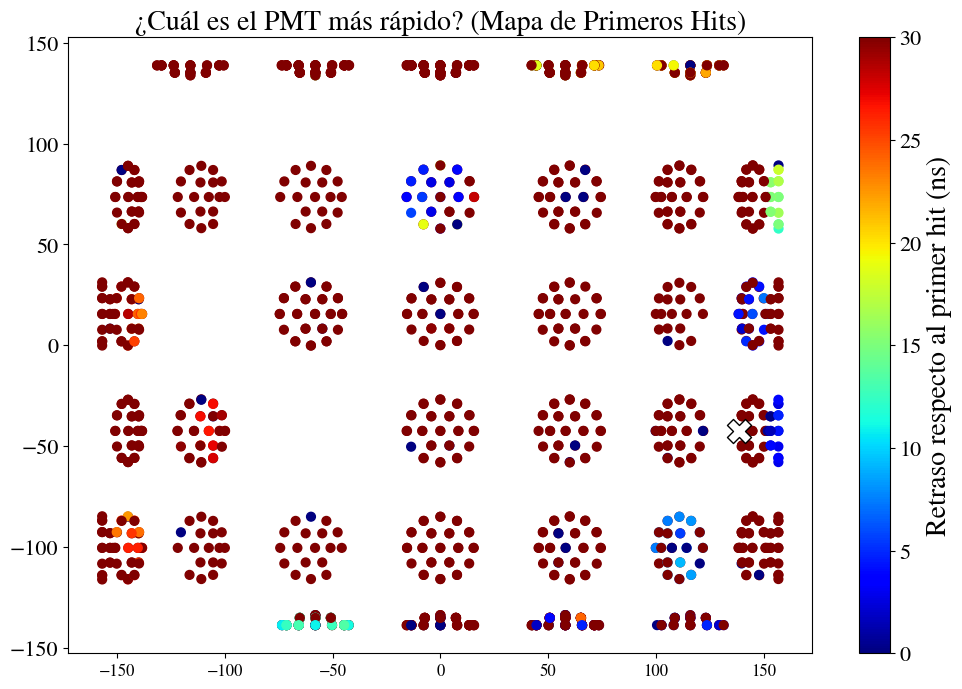

In [11]:
# Vamos a procesar evento por evento para encontrar el origen
data = tree.arrays(["hit_mpmt_slot_ids", "hit_pmt_position_ids", "hit_pmt_times"], entry_stop=100)

pmt_min_times = {}

for ev_slots, ev_pos, ev_times in zip(data["hit_mpmt_slot_ids"], 
                                      data["hit_pmt_position_ids"], 
                                      data["hit_pmt_times"]):
    if len(ev_times) == 0: continue
    
    t_start = ak.min(ev_times) # El primer hit del evento
    
    for s, p, t in zip(ev_slots, ev_pos, ev_times):
        key = (int(s), int(p))
        if key not in lookup: key = (int(s), int(p) + 1)
        
        if key in lookup:
            t_rel = t - t_start # Tiempo relativo al inicio del evento
            if key not in pmt_min_times or t_rel < pmt_min_times[key]:
                pmt_min_times[key] = t_rel

# Convertir para plotear
plot_z, plot_y, plot_t = [], [], []
for key, t_min in pmt_min_times.items():
    pos = lookup[key]
    plot_z.append(pos[2])
    plot_y.append(pos[1])
    plot_t.append(t_min)

plt.figure(figsize=(12, 8))
sc = plt.scatter(plot_z, plot_y, c=plot_t, s=40, cmap='jet', vmax=30) # Vmax=30ns para ver el detalle
plt.colorbar(label='Retraso respecto al primer hit (ns)')
plt.scatter(138.79, -42.47, color='white', edgecolors='black', marker='X', s=300, label='Tu Haz')
plt.title("¿Cuál es el PMT más rápido? (Mapa de Primeros Hits)")
plt.show()

In [12]:
# Coordenadas de tu hueco teórico
target_y, target_z = -42.47, 138.79

# Buscamos PMTs en un radio de 20cm alrededor de ese punto
hits_near_target = []
for key, t_min in pmt_min_times.items():
    pos = lookup[key]
    dist = np.sqrt((pos[1] - target_y)**2 + (pos[2] - target_z)**2)
    if dist < 20:
        hits_near_target.append(t_min)

if hits_near_target:
    print(f"Tiempo mínimo promedio cerca de tu HAZ: {np.mean(hits_near_target):.2f} ns")
else:
    print("No hay PMTs cerca de tu coordenada de haz.")

# Ahora buscamos el punto que REALMENTE tiene el tiempo mínimo global
min_key = min(pmt_min_times, key=pmt_min_times.get)
best_pos = lookup[min_key]
print(f"El PMT más rápido REAL está en: X={best_pos[0]:.2f}, Y={best_pos[1]:.2f}, Z={best_pos[2]:.2f}")
print(f"Con un tiempo de: {pmt_min_times[min_key]:.2f} ns")

Tiempo mínimo promedio cerca de tu HAZ: 43.99 ns
El PMT más rápido REAL está en: X=-49.68, Y=135.19, Z=-116.00
Con un tiempo de: 0.00 ns


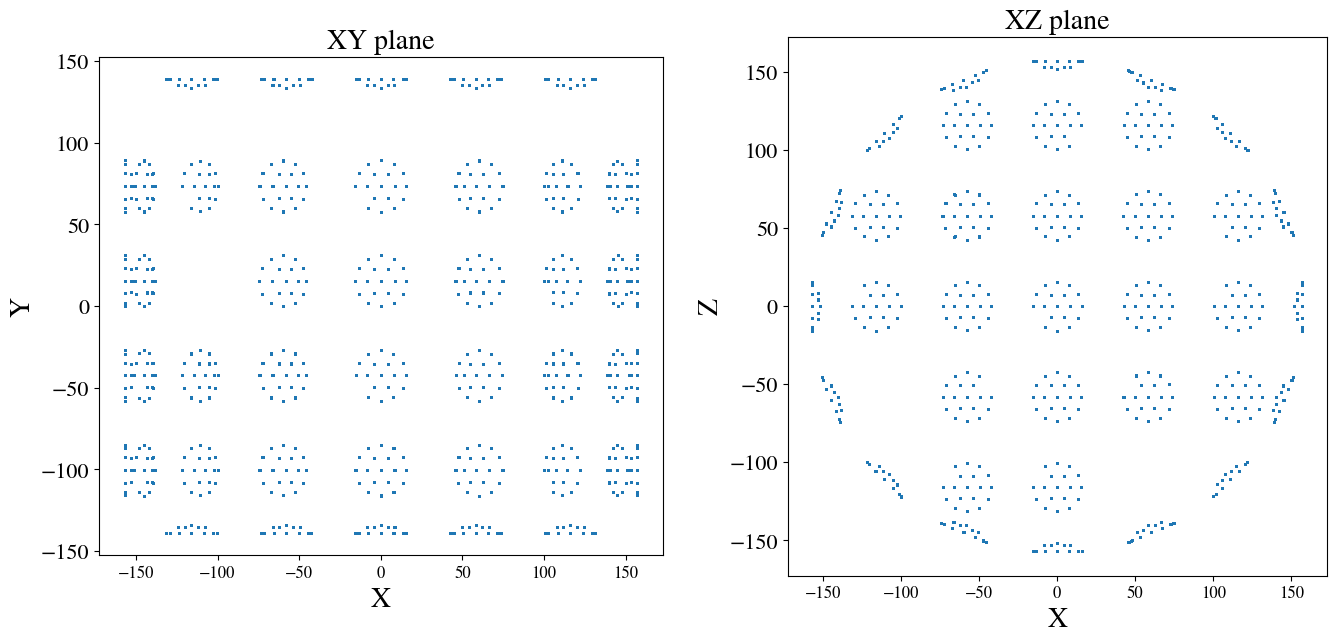

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Test plano X-Y
ax[0].scatter(all_x, all_y, s=1, alpha=0.5)
ax[0].set_title("XY plane")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")
ax[0].set_aspect('equal')

# Test plano X-Z
ax[1].scatter(all_x, all_z, s=1, alpha=0.5)
ax[1].set_title("XZ plane")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Z")
ax[1].set_aspect('equal')

plt.show()

In [3]:
branches = [
    "window_time",
    "start_counter",
    "spill_counter",
    "event_number",
    "readout_number",

    "hit_mpmt_card_ids",
    "hit_pmt_channel_ids",
    "hit_mpmt_slot_ids",
    "hit_pmt_position_ids",
    "hit_pmt_charges",
    "hit_pmt_times",
    "hit_pmt_calibrated_times"
]

N = 10000  #109 spills 

arrays = tree.arrays(
    branches,
    entry_start=0,
    entry_stop=N,
    library="ak"
)

print("Loaded events:", len(arrays.window_time))

print("Loaded branches:")
print(arrays.fields)

#total: 1.194.724

Loaded events: 10000
Loaded branches:
['window_time', 'start_counter', 'spill_counter', 'event_number', 'readout_number', 'hit_mpmt_card_ids', 'hit_pmt_channel_ids', 'hit_mpmt_slot_ids', 'hit_pmt_position_ids', 'hit_pmt_charges', 'hit_pmt_times', 'hit_pmt_calibrated_times']


In [4]:
print("How many readout windows in this part file (with window_time):", len(arrays["window_time"]))         #each element here corresponds to one readout window 
print("How many readout windows in this part file (with readout_number):", len(arrays["readout_number"]))   #same number as the one given with window_time

print("How many hits per window (with hit_pmt_charges):", ak.num(arrays["hit_pmt_charges"])[:10])    #(10 first)
print("How many hits per window (with hit_pmt_times):", ak.num(arrays["hit_pmt_times"])[:10])   

"""
We have 4950 readout windows in part_file P1000 from Run1848 
In the first readout window, there are 969 hits
In the second readout window, there are 647 hits...
"""

print("start_counter:", arrays["start_counter"])
print("spill_counter:", arrays["spill_counter"])
print("readout_number:", arrays["readout_number"])

print("hit_pmt_charges:", arrays["hit_pmt_charges"])
print("hit_pmt_times:", arrays["hit_pmt_times"])

How many readout windows in this part file (with window_time): 10000
How many readout windows in this part file (with readout_number): 10000
How many hits per window (with hit_pmt_charges): [836, 735, 6436, 1246, 3566, 11104, 4955, 5436, 9275, 3833]
How many hits per window (with hit_pmt_times): [836, 735, 6436, 1246, 3566, 11104, 4955, 5436, 9275, 3833]
start_counter: [1900853517, 1901165137, 1903727670, ..., 12720304140, 12720317838, 12720357296]
spill_counter: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
readout_number: [0, 1, 2, 3, 4, 5, 6, 8, 9, ..., 9942, 9948, 9951, 9955, 9959, 9964, 9970, 9974]
hit_pmt_charges: [[150, 142, 165, 153, 187, 149, 111, ..., 182, 237, 109, 50, 76, 423, 47], ...]
hit_pmt_times: [[4.37e+04, 8.25e+04, 9.7e+04, ..., 8.68e+04, 9.63e+04, 9.91e+04], ..., [...]]


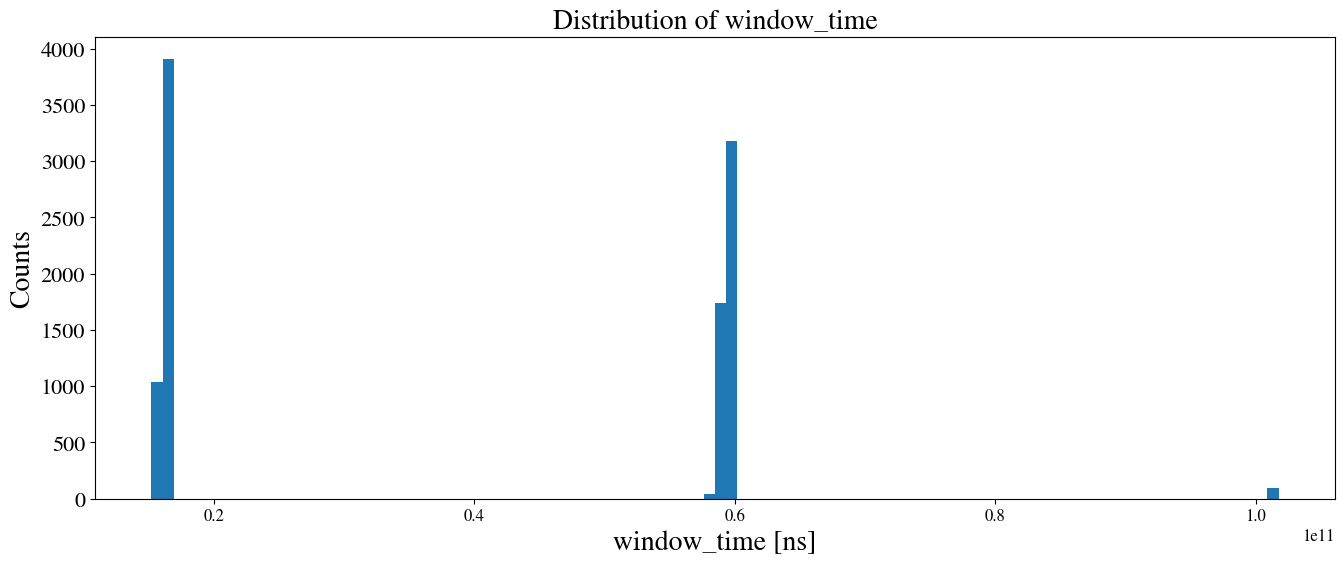

In [5]:
plt.hist(arrays.window_time, bins=100)   #window_time es el tiempo absoluto de la ventana[i], un único valo por ventana 
                                        #todos los hits de una misma ventana comparten el mismo window_time[i] como referencia.
plt.xlabel("window_time [ns]")
plt.ylabel("Counts")
plt.title("Distribution of window_time")
plt.show()

#distribution estamos viendo solo los tiempos de las ventanas, no de los hits dentro de ellas

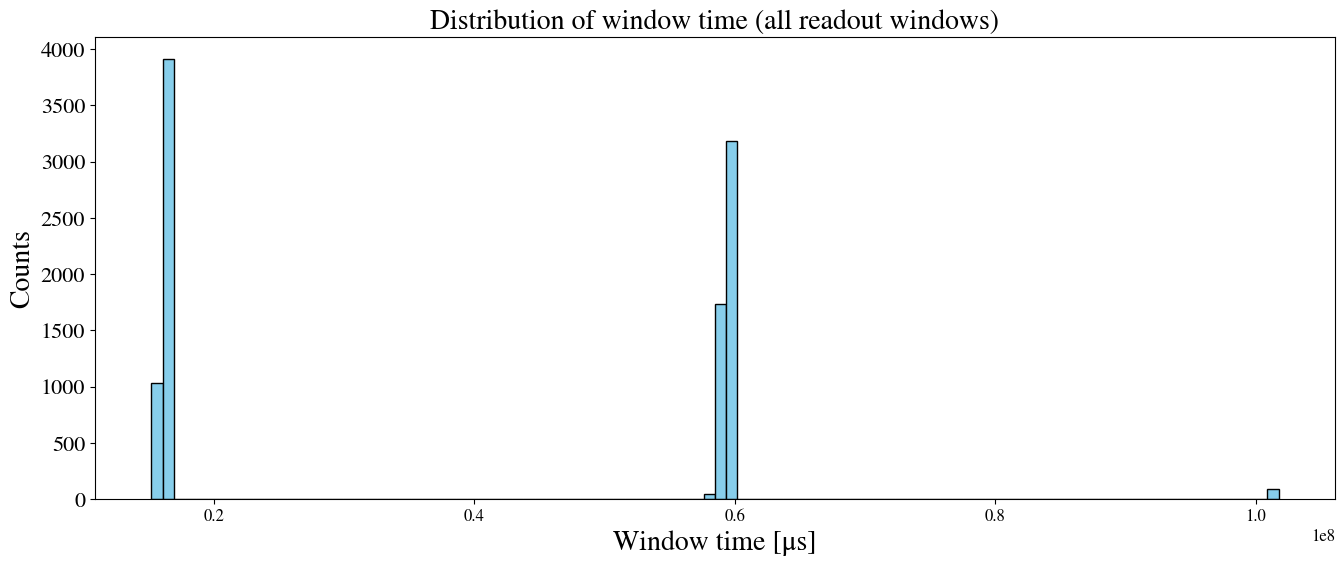

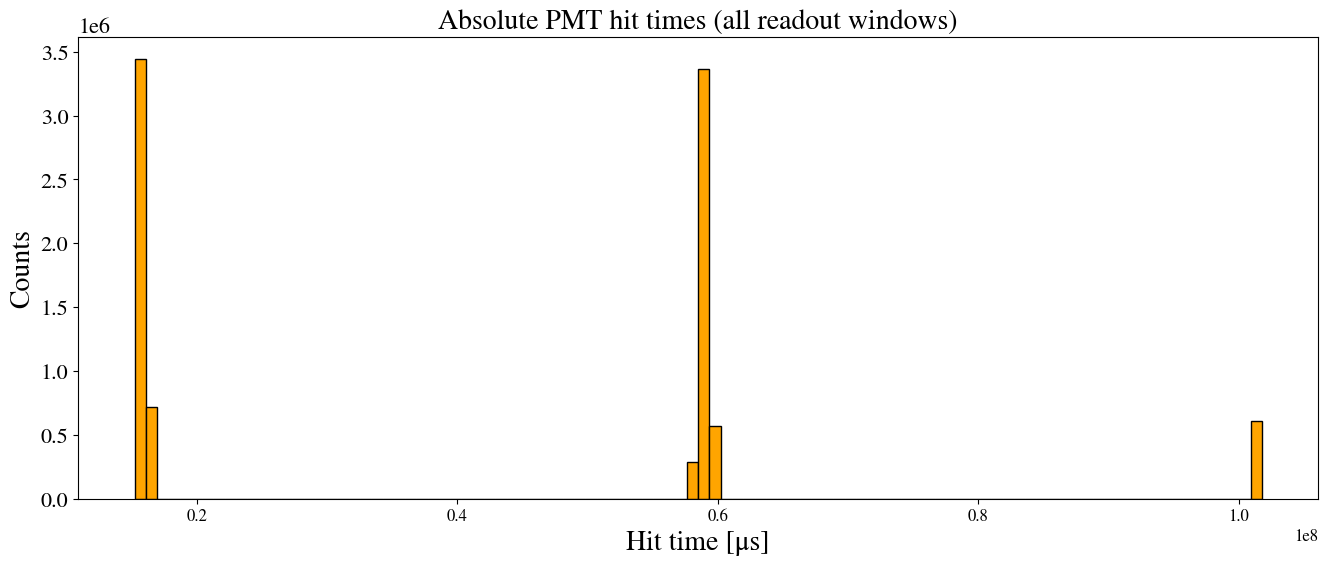

In [6]:
window_times_us = arrays.window_time / 1000  # convertir de ns -> μs

plt.hist(window_times_us, bins=100, color='skyblue', edgecolor='k')
plt.xlabel("Window time [μs]")
plt.ylabel("Counts")
plt.title("Distribution of window time (all readout windows)")
plt.show()

#--------------------------------------------------------------------------------
hit_times = arrays.window_time[:, None] + arrays.hit_pmt_calibrated_times
all_hit_times_us = ak.flatten(hit_times) / 1000  # μs

plt.hist(all_hit_times_us, bins=100, color='orange', edgecolor='k')
plt.xlabel("Hit time [μs]")
plt.ylabel("Counts")
plt.title("Absolute PMT hit times (all readout windows)")
plt.show()

In [7]:
threshold_us = 1e6  # 1 second
window_times_us = np.sort(arrays.window_time / 1000)
delta_t_us = np.diff(window_times_us)
spill_boundaries = np.where(delta_t_us > threshold_us)[0]

# índice donde termina spill 0
idx = spill_boundaries[0]

# último window_time del spill 0
t_last_spill0 = window_times_us[idx]

# primer window_time del spill 1
t_first_spill1 = window_times_us[idx + 1]

# Δt en μs
delta_t_us = t_first_spill1 - t_last_spill0

# en segundos
delta_t_s = delta_t_us / 1e6

print("Δt between spill 0 and spill 1:")
print(delta_t_us, "μs")
print(delta_t_s, "s")

Δt between spill 0 and spill 1:
41903776.512 μs
41.903776512 s


In [8]:
window_times_us = np.array(arrays.window_time / 1000)

dt = np.diff(window_times_us)

threshold = 0.3e8

spill_boundaries = np.where(dt > threshold)[0]

spill_starts = np.insert(spill_boundaries + 1, 0, 0)
spill_ends   = np.append(spill_boundaries, len(window_times_us) - 1)

for i, (start, end) in enumerate(zip(spill_starts, spill_ends)):
    print(f"Spill {i}:")
    print("   start =", window_times_us[start])
    print("   end   =", window_times_us[end])


print("Spill 0 end:", window_times_us[spill_ends[0]])
print("Spill 1 start:", window_times_us[spill_starts[1]])
print("Δt between windows [μs]:", window_times_us[spill_starts[1]] - window_times_us[spill_ends[0]])


Spill 0:
   start = 15206828.136
   end   = 16506958.6
Spill 1:
   start = 58410735.112
   end   = 59703991.6
Spill 2:
   start = 101615367.816
   end   = 101762858.368
Spill 0 end: 16506958.6
Spill 1 start: 58410735.112
Δt between windows [μs]: 41903776.512


In [9]:
spill0_end = window_times_us[spill_ends[0]]
spill1_end = window_times_us[spill_ends[1]]

#seleccionar hits después del spill
hits_after_spill0 = all_hit_times_us[all_hit_times_us > spill0_end]  #cuidaod, aquí entran TODOS después del spill0 (i.e. spill1 y spill2)

print("Spill 0 end:", spill0_end)
print("Total hits:", len(all_hit_times_us))
print("Hits after spill 0:", len(hits_after_spill0))

print("Primeros hits after spill:")
print(hits_after_spill0[:10])

print("Últimos hits after spill:")
print(hits_after_spill0[-10:])

print("Max window_time:", np.max(window_times_us))
print("Max hit_time:", np.max(all_hit_times_us))

Spill 0 end: 16506958.6
Total hits: 8996301
Hits after spill 0: 4829807
Primeros hits after spill:
[1.65e+07, 1.65e+07, 1.65e+07, 1.65e+07, ..., 1.65e+07, 1.65e+07, 1.65e+07]
Últimos hits after spill:
[1.02e+08, 1.02e+08, 1.02e+08, 1.02e+08, ..., 1.02e+08, 1.02e+08, 1.02e+08]
Max window_time: 101762858.368
Max hit_time: 101762960.6693462


In [10]:
spill1_start = window_times_us[spill_starts[1]] #cogemos solo los que están justo después del spill0

hits_after_spill0_clean = all_hit_times_us[
    (all_hit_times_us > spill0_end) &
    (all_hit_times_us < spill1_start)
]

print("Hits right after spill 0:", len(hits_after_spill0_clean))

spill2_start = window_times_us[spill_starts[2]] #cogemos solo los que están justo después del spill0

hits_after_spill1_clean = all_hit_times_us[
    (all_hit_times_us > spill1_end) &
    (all_hit_times_us < spill2_start)
]

print("Hits right after spill 1:", len(hits_after_spill1_clean))

Hits right after spill 0: 57
Hits right after spill 1: 58


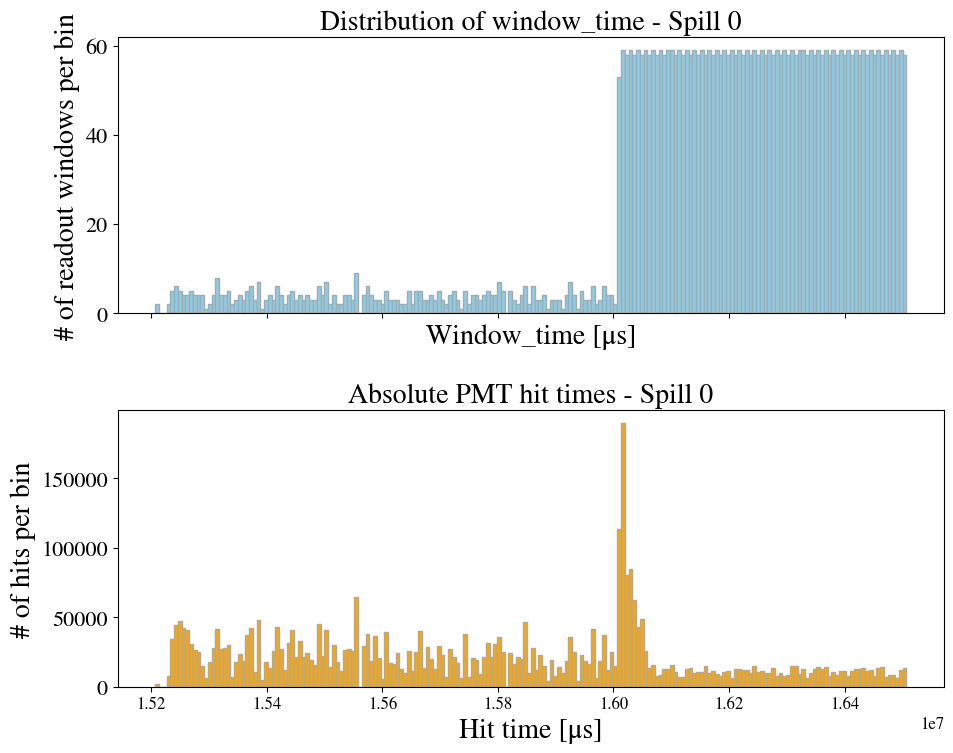

In [11]:
spill_to_analyze = 0
spill_mask = arrays.spill_counter == spill_to_analyze
arrays_spill = arrays[spill_mask]

# -----------------------------
window_times_us = ak.to_numpy(arrays_spill.window_time) / 1000  #ns -> μs

hit_times_spill = arrays_spill.window_time[:, None] + arrays_spill.hit_pmt_calibrated_times
all_hit_times_spill_us = ak.to_numpy(ak.flatten(hit_times_spill)) / 1000  # ns -> μs

#binning común
combined_data = np.concatenate([window_times_us, all_hit_times_spill_us])
bins = np.histogram_bin_edges(combined_data, bins=200)

# -----------------------------
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

#window_times
axs[0].hist(window_times_us, bins=bins, color='skyblue', edgecolor='darkgray')
axs[0].set_ylabel("# of readout windows per bin")
axs[0].set_xlabel("Window_time [μs]")
axs[0].set_title(f"Distribution of window_time - Spill {spill_to_analyze}")

#hit_times
axs[1].hist(all_hit_times_spill_us, bins=bins, color='orange', edgecolor='darkgray')
axs[1].set_xlabel("Hit time [μs]")
axs[1].set_ylabel("# of hits per bin")
axs[1].set_title(f"Absolute PMT hit times - Spill {spill_to_analyze}")

plt.tight_layout()
plt.show()

Spills: [0, 1, 2]


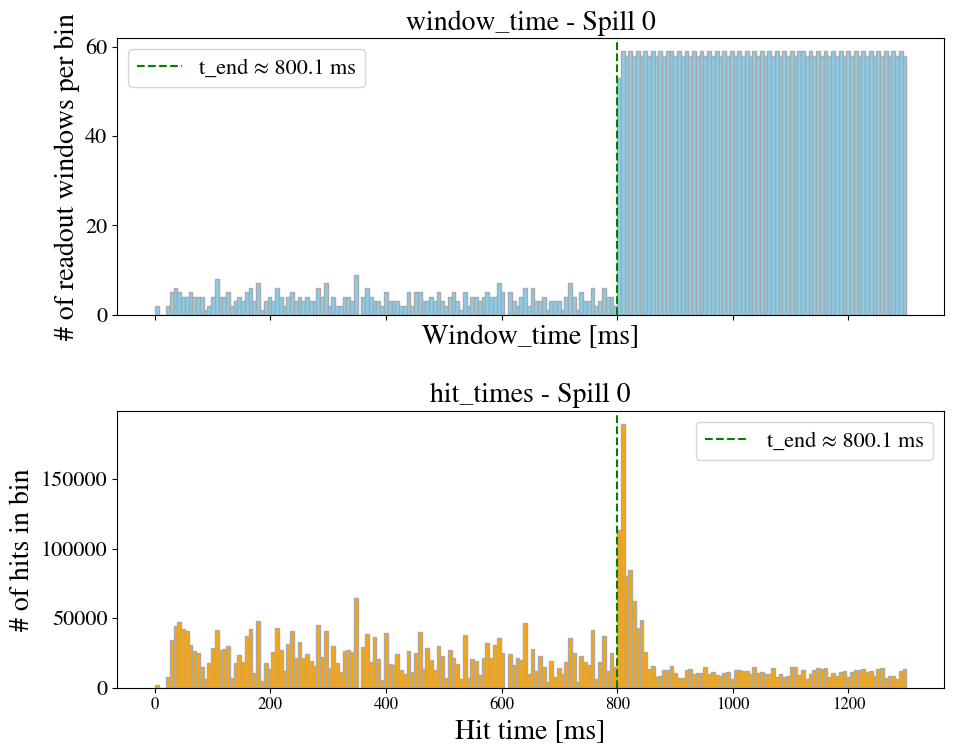

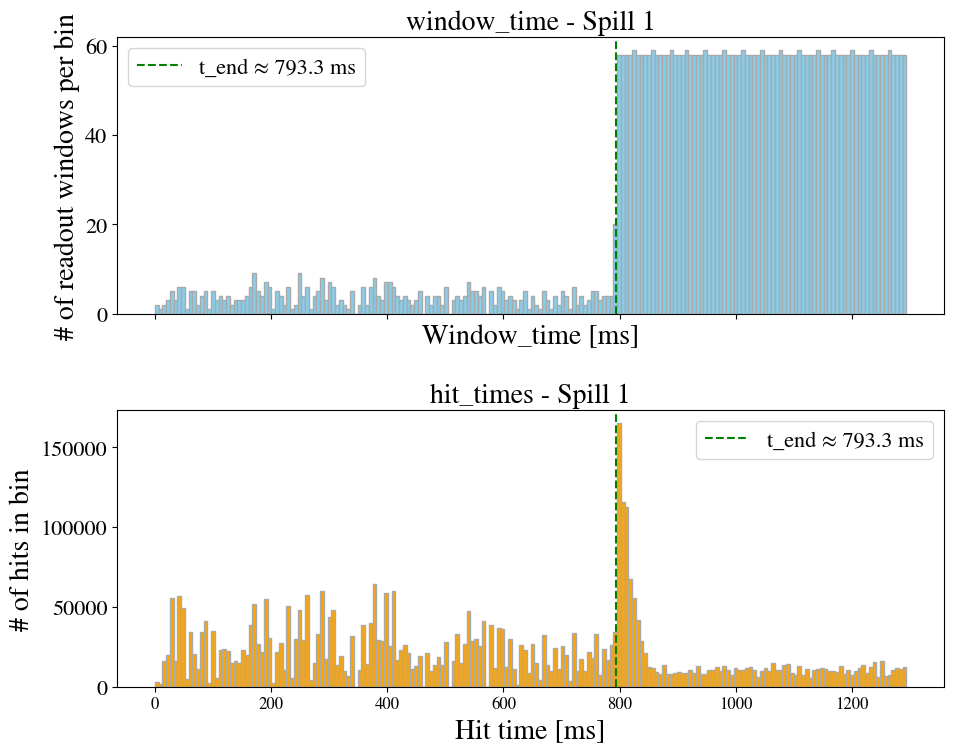

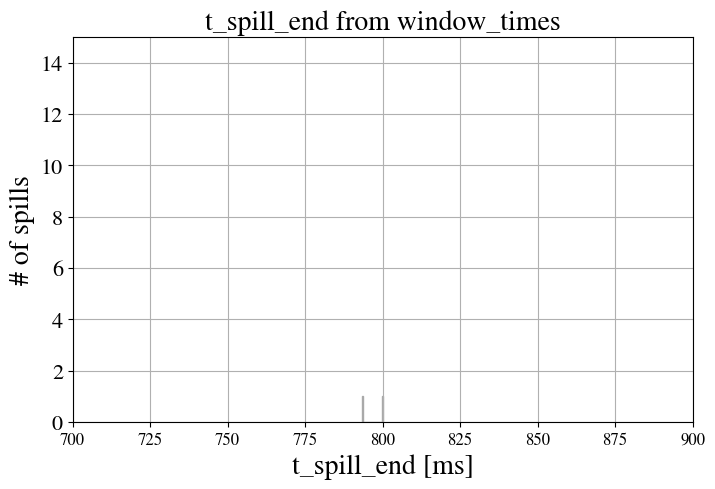

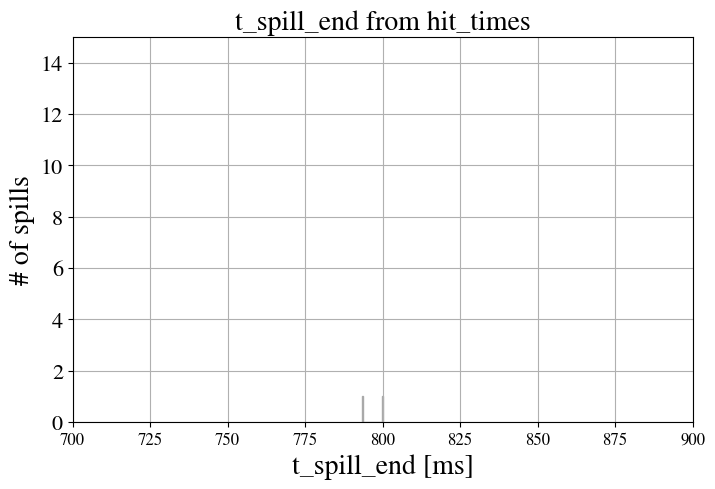

Window-based t_spill_end: [np.float64(800.1304639999996), np.float64(793.256487999998)]
Hit-based t_spill_end: [np.float64(800.1304639999996), np.float64(793.256487999998)]
Mean window: 796.6934759999988
Mean hit: 796.6934759999988
Std window: 3.436988000000838
Std hit: 3.436988000000838


In [12]:
unique_spills = np.unique(arrays.spill_counter)
print("Spills:", unique_spills)

t_spill_end_window_list = []
t_spill_end_hit_list = []

for spill_to_analyze in unique_spills[:-1]:
    spill_mask = arrays.spill_counter == spill_to_analyze
    arrays_spill = arrays[spill_mask]

    # -----------------------------
    window_times_us = ak.to_numpy(arrays_spill.window_time) / 1000
    window_times_rel_us = window_times_us - np.min(window_times_us)
    window_times_rel = window_times_rel_us / 1000  # ms

    hit_times_spill = arrays_spill.window_time[:, None] + arrays_spill.hit_pmt_calibrated_times
    all_hit_times_spill_us = ak.to_numpy(ak.flatten(hit_times_spill)) / 1000
    hit_times_rel_us = all_hit_times_spill_us - np.min(window_times_us)
    hit_times_rel = hit_times_rel_us / 1000  # ms

    # -----------------------------
    # NEW t_spill_end from time (last 0.5 s)
    if len(window_times_rel) > 0:
        t_max = np.max(window_times_rel)
        t_spill_end = t_max - 500  # ms

        t_spill_end_window_list.append(t_spill_end)
        t_spill_end_hit_list.append(t_spill_end)
    else:
        t_spill_end = None

    # -----------------------------
    # binning común
    combined_data = np.concatenate([window_times_rel, hit_times_rel])
    bins = np.histogram_bin_edges(combined_data, bins=200)

    # -----------------------------
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

    # =============================
    # WINDOW TIMES
    axs[0].hist(window_times_rel, bins=bins, color='skyblue', edgecolor='darkgray')

    if t_spill_end is not None:
        axs[0].axvline(
            t_spill_end,
            color='green',
            linestyle='--',
            label=f't_end ≈ {t_spill_end:.1f} ms'
        )

    axs[0].set_ylabel("# of readout windows per bin")
    axs[0].set_xlabel("Window_time [ms]")
    axs[0].set_title(f"window_time - Spill {spill_to_analyze}")
    axs[0].legend()

    # =============================
    # HIT TIMES
    axs[1].hist(hit_times_rel, bins=bins, color='orange', edgecolor='darkgray')

    if t_spill_end is not None:
        axs[1].axvline(
            t_spill_end,
            color='green',
            linestyle='--',
            label=f't_end ≈ {t_spill_end:.1f} ms'
        )

    axs[1].set_xlabel("Hit time [ms]")
    axs[1].set_ylabel("# of hits in bin")
    axs[1].set_title(f"hit_times - Spill {spill_to_analyze}")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

# =============================
# HISTOGRAMAS FINALES

plt.figure(figsize=(8,5))
plt.hist(t_spill_end_window_list, bins=20, edgecolor='darkgray')
plt.xlabel("t_spill_end [ms]")
plt.ylabel("# of spills")
plt.title("t_spill_end from window_times")
plt.xlim(700, 900)
plt.ylim(0, 15)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(t_spill_end_hit_list, bins=20, edgecolor='darkgray')
plt.xlabel("t_spill_end [ms]")
plt.ylabel("# of spills")
plt.title("t_spill_end from hit_times")
plt.xlim(700, 900)
plt.ylim(0, 15)
plt.grid(True)
plt.show()

print("Window-based t_spill_end:", t_spill_end_window_list)
print("Hit-based t_spill_end:", t_spill_end_hit_list)

print("Mean window:", np.mean(t_spill_end_window_list))
print("Mean hit:", np.mean(t_spill_end_hit_list))

print("Std window:", np.std(t_spill_end_window_list))
print("Std hit:", np.std(t_spill_end_hit_list))

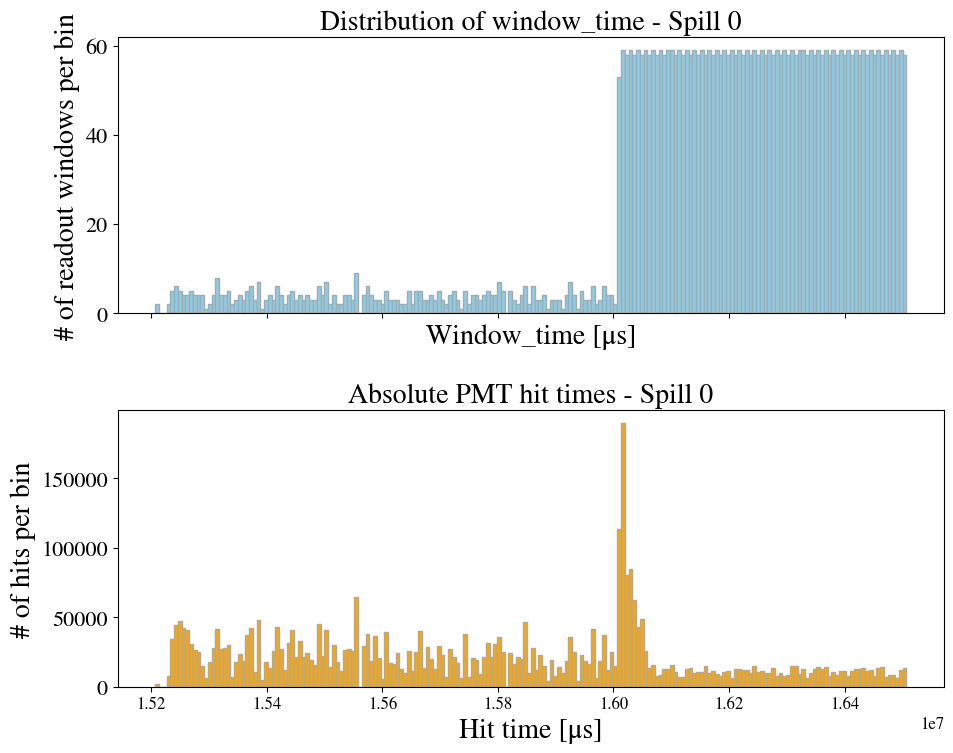

In [ ]:
spill_to_analyze = 0
spill_mask = arrays.spill_counter == spill_to_analyze
arrays_spill = arrays[spill_mask]

# -----------------------------
window_times_us = ak.to_numpy(arrays_spill.window_time) / 1000  #ns -> μs

hit_times_spill = arrays_spill.window_time[:, None] + arrays_spill.hit_pmt_calibrated_times
all_hit_times_spill_us = ak.to_numpy(ak.flatten(hit_times_spill)) / 1000  # ns -> μs

#binning común
combined_data = np.concatenate([window_times_us, all_hit_times_spill_us])
bins = np.histogram_bin_edges(combined_data, bins=200)

# -----------------------------
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

#window_times
axs[0].hist(window_times_us, bins=bins, color='skyblue', edgecolor='darkgray')
axs[0].set_ylabel("# of readout windows per bin")
axs[0].set_xlabel("Window_time [μs]")
axs[0].set_title(f"Distribution of window_time - Spill {spill_to_analyze}")

#hit_times
axs[1].hist(all_hit_times_spill_us, bins=bins, color='orange', edgecolor='darkgray')
axs[1].set_xlabel("Hit time [μs]")
axs[1].set_ylabel("# of hits per bin")
axs[1].set_title(f"Absolute PMT hit times - Spill {spill_to_analyze}")

plt.tight_layout()
plt.show()

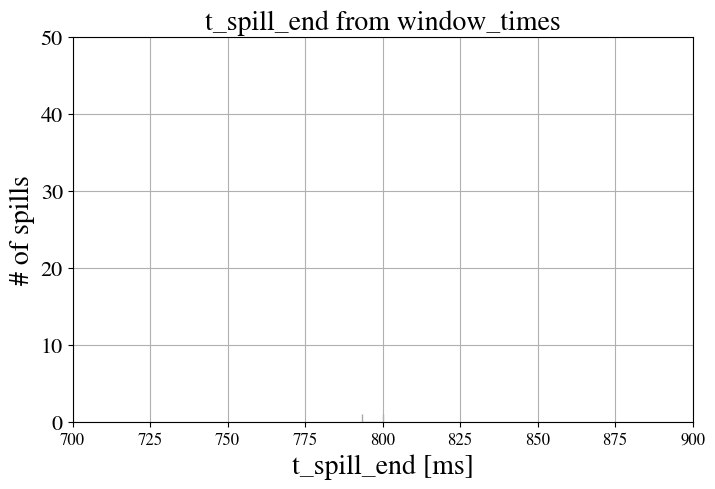

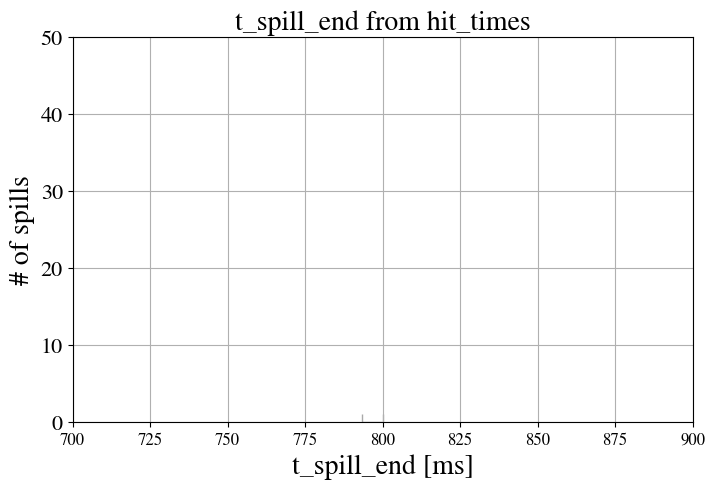

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# =============================
# HISTOGRAMA: WINDOW-BASED t_spill_end

plt.figure(figsize=(8,5))
plt.hist(t_spill_end_window_list, bins=200, edgecolor='darkgray')
plt.xlabel("t_spill_end [ms]")
plt.ylabel("# of spills")
plt.title("t_spill_end from window_times")
plt.xlim(700, 900)
plt.ylim(0, 50)
plt.grid(True)
plt.show()

# =============================
# HISTOGRAMA: HIT-BASED t_spill_end

plt.figure(figsize=(8,5))
plt.hist(t_spill_end_hit_list, bins=200, edgecolor='darkgray')
plt.xlabel("t_spill_end [ms]")
plt.ylabel("# of spills")
plt.title("t_spill_end from hit_times")
plt.xlim(700, 900)
plt.ylim(0, 50)
plt.grid(True)
plt.show()

In [15]:
def nHitsTimeWindow(times_branch_event_arg, threshold_inf, window, death_window, charge_branch_event = [], threshold_sup = np.inf):
    times_branch_event = np.sort(times_branch_event_arg.copy()) #just to make sure, but it is supposed to be sorted

    threshold_times = []
    nhits_range = []

    i = 0
    n = len(times_branch_event)

    while i < n:
        time_hit = times_branch_event[i]
        mask = (times_branch_event >= time_hit) & (times_branch_event < time_hit + window)

        if len(charge_branch_event)!=0:
            count = max(charge_branch_event[mask])
        else:
            count = mask.sum()

        if count > threshold_inf and count<threshold_sup:
            threshold_times.append(time_hit)
            nhits_range.append(count)
            # Zero out the next death window ns after the hit window
            mask_2 = (times_branch_event >= time_hit) & (times_branch_event < time_hit + window + death_window)

            indices = np.where(mask_2)[0]

            # Jump ahead by death window
            i += 1
            while i < n and times_branch_event[i] < time_hit + window + death_window:
                i += 1
        else:
            i += 1

    return threshold_times, nhits_range

In [18]:
threshold_inf = 15
threshold_sup = 40
window = 25  # ns
death_window = 0  # or maybe larger, see below

spill_to_analyze = 0
spill_mask = arrays.spill_counter == spill_to_analyze
arrays_spill = arrays[spill_mask]

# absolute hit times (ns)
hit_times = arrays_spill.window_time[:, None] + arrays_spill.hit_pmt_calibrated_times
all_hit_times = ak.to_numpy(ak.flatten(hit_times))

threshold_times, nhits_range = nHitsTimeWindow(
    all_hit_times,
    threshold_inf=15,
    threshold_sup=40,
    window=25,
    death_window=25  # important parameter!
)

print("Number of candidates:", len(threshold_times))
print("First few:", threshold_times[:10], nhits_range[:10])

KeyboardInterrupt: 